# Multi-Dimensional Retail Analytics

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm   
from scipy import stats

## Importing data

In [2]:
raw = pd.read_csv('customer_shopping_data.csv')
data = raw.copy()

In [3]:
column = data.shape[1]
row = data.shape[0]

print(f'Column count: {column}')
print(f'Rows count: {row}')

data.head()

Column count: 10
Rows count: 99457


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [4]:
data.columns = data.columns.str.lower()
data = data.map(lambda x: x.lower() if isinstance(x,str) else x)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 12.9 MB


In [6]:
print(f'The count of empty cells: {data.isnull().sum().sum()}')
print(f'The count of duplicated rows: {data.duplicated().sum()}')
print(f'Invice_no wether unique: {data['invoice_no'].is_unique}')
print(f'Wether customer_id unique: {data['customer_id'].is_unique}')


The count of empty cells: 0
The count of duplicated rows: 0
Invice_no wether unique: True
Wether customer_id unique: True


In [7]:
print(f'The min of quantity: {data['quantity'].min()}')
print(f'The max of quantity: {data['quantity'].max()}')
print(f'The max of age: {data['age'].max()}')
print(f'The min of age: {data['age'].min()}')

The min of quantity: 1
The max of quantity: 5
The max of age: 69
The min of age: 18


In [8]:
data.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [9]:
for column in ['gender','category','payment_method','shopping_mall']:
    spaces = (data[column] != data[column].str.strip()).sum()
    print(f'{column} - the count of extra spaces is {spaces}')
    print(data[column].value_counts())
    print('--------------------------------')

gender - the count of extra spaces is 0
gender
female    59482
male      39975
Name: count, dtype: int64
--------------------------------
category - the count of extra spaces is 0
category
clothing           34487
cosmetics          15097
food & beverage    14776
toys               10087
shoes              10034
souvenir            4999
technology          4996
books               4981
Name: count, dtype: int64
--------------------------------
payment_method - the count of extra spaces is 0
payment_method
cash           44447
credit card    34931
debit card     20079
Name: count, dtype: int64
--------------------------------
shopping_mall - the count of extra spaces is 0
shopping_mall
mall of istanbul     19943
kanyon               19823
metrocity            15011
metropol avm         10161
istinye park          9781
zorlu center          5075
cevahir avm           4991
forum istanbul        4947
viaport outlet        4914
emaar square mall     4811
Name: count, dtype: int64
----------

Just checking if there is any other price 

## Price tests

In [10]:
clothing_rows = data[data['category']=='clothing']
clothing_check = clothing_rows.groupby('quantity')['price'].agg(['min','max','nunique'])

In [11]:
clothing_check

,min,max,nunique
quantity,,,
1,300.08,300.08,1
2,600.16,600.16,1
3,900.24,900.24,1
4,1200.32,1200.32,1
5,1500.40,1500.40,1


In [12]:
data['unit_price'] = (data['price']/data['quantity']).round(2)

unit_price_check = data.groupby('category')['unit_price'].agg(['nunique','min','max'])
print('Unit price for evry category')
unit_price_check

Unit price for evry category


,nunique,min,max
category,,,
books,1,15.15,15.15
clothing,1,300.08,300.08
cosmetics,1,40.66,40.66
food & beverage,1,5.23,5.23
shoes,1,600.17,600.17
souvenir,1,11.73,11.73
technology,1,1050.00,1050.00
toys,1,35.84,35.84


## Analysis

### Analysis

In [13]:
data['invoice_date']

0          5/8/2022
1        12/12/2021
2         9/11/2021
3        16/05/2021
4        24/10/2021
            ...    
99452    21/09/2022
99453    22/09/2021
99454    28/03/2021
99455    16/03/2021
99456    15/10/2022
Name: invoice_date, Length: 99457, dtype: str

In [14]:
data['invoice_date'] = pd.to_datetime(data['invoice_date'], format="%d/%m/%Y")
data['invoice_date']

0       2022-08-05
1       2021-12-12
2       2021-11-09
3       2021-05-16
4       2021-10-24
           ...    
99452   2022-09-21
99453   2021-09-22
99454   2021-03-28
99455   2021-03-16
99456   2022-10-15
Name: invoice_date, Length: 99457, dtype: datetime64[us]

In [15]:
data['year'] = data['invoice_date'].dt.year
data['month'] = data['invoice_date'].dt.month
data['year_month'] = data['invoice_date'].dt.strftime("%Y-%m")
data["revenue"] = data["price"] 

In [16]:
age_bins = [17,24,34,44,54,64,69]
age_labels = ['17-24','25-34','35-44','45-54','55-64','65-69']
data['age_group'] = pd.cut(data['age'],bins= age_bins,labels= age_labels)
data[["invoice_no", "invoice_date", "year", "month", "year_month", "category", "quantity", "revenue", "age_group"]].head()

,invoice_no,invoice_date,year,month,year_month,category,quantity,revenue,age_group
0,i138884,2022-08-05,2022,8,2022-08,clothing,5,1500.40,25-34
1,i317333,2021-12-12,2021,12,2021-12,shoes,3,1800.51,17-24
2,i127801,2021-11-09,2021,11,2021-11,clothing,1,300.08,17-24
3,i173702,2021-05-16,2021,5,2021-05,shoes,5,3000.85,65-69
4,i337046,2021-10-24,2021,10,2021-10,books,4,60.60,45-54


In [17]:
data

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,unit_price,year,month,year_month,revenue,age_group
0,i138884,c241288,female,28,clothing,5,1500.40,credit card,2022-08-05,kanyon,300.08,2022,8,2022-08,1500.40,25-34
1,i317333,c111565,male,21,shoes,3,1800.51,debit card,2021-12-12,forum istanbul,600.17,2021,12,2021-12,1800.51,17-24
2,i127801,c266599,male,20,clothing,1,300.08,cash,2021-11-09,metrocity,300.08,2021,11,2021-11,300.08,17-24
3,i173702,c988172,female,66,shoes,5,3000.85,credit card,2021-05-16,metropol avm,600.17,2021,5,2021-05,3000.85,65-69
4,i337046,c189076,female,53,books,4,60.60,cash,2021-10-24,kanyon,15.15,2021,10,2021-10,60.60,45-54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99452,i219422,c441542,female,45,souvenir,5,58.65,credit card,2022-09-21,kanyon,11.73,2022,9,2022-09,58.65,45-54
99453,i325143,c569580,male,27,food & beverage,2,10.46,cash,2021-09-22,forum istanbul,5.23,2021,9,2021-09,10.46,25-34
99454,i824010,c103292,male,63,food & beverage,2,10.46,debit card,2021-03-28,metrocity,5.23,2021,3,2021-03,10.46,55-64
99455,i702964,c800631,male,56,technology,4,4200.00,cash,2021-03-16,istinye park,1050.00,2021,3,2021-03,4200.00,55-64


In [18]:
sns.set_theme(style="whitegrid")

total_revenue = data['revenue'].sum()
first_date = data['invoice_date'].min().date()
last_date = data['invoice_date'].max().date()

print(f'Total revenue: {total_revenue:,.0f}')
print(f'Date range: {first_date} -> {last_date}')
print()
print('Invoices and revenue per year (2023 is partial):')
data.groupby('year')['revenue'].agg(['count', 'sum']).round(0)

Total revenue: 68,551,366
Date range: 2021-01-01 -> 2023-03-08

Invoices and revenue per year (2023 is partial):


,count,sum
year,,
2021,45382,31316305.0
2022,45551,31372826.0
2023,8524,5862235.0


### 1. Spending

In [19]:
spending_columns = ['category', 'shopping_mall', 'payment_method', 'gender']
spending_tables = {}


In [20]:

for column in spending_columns:
    table = data.groupby(column)['revenue'].agg(['sum', 'mean', 'count'])
    table.columns = ['total_revenue', 'avg_purchase', 'transactions']
    table['revenue_share_%'] = table['total_revenue'] / total_revenue * 100
    table = table.sort_values('total_revenue', ascending=False).round(2)
    spending_tables[column] = table

    print(f'--- Spending by {column} ---')
    display(table)

--- Spending by category ---


,total_revenue,avg_purchase,transactions,revenue_share_%
category,,,,
clothing,31075684.64,901.08,34487,45.33
shoes,18135336.89,1807.39,10034,26.46
technology,15772050.00,3156.94,4996,23.01
cosmetics,1848606.90,122.45,15097,2.70
toys,1086704.64,107.73,10087,1.59
food & beverage,231568.71,15.67,14776,0.34
books,226977.30,45.57,4981,0.33
souvenir,174436.83,34.89,4999,0.25


--- Spending by shopping_mall ---


,total_revenue,avg_purchase,transactions,revenue_share_%
shopping_mall,,,,
mall of istanbul,13851737.62,694.57,19943,20.21
kanyon,13710755.24,691.66,19823,20.00
metrocity,10249980.07,682.83,15011,14.95
metropol avm,6937992.99,682.81,10161,10.12
istinye park,6717077.54,686.75,9781,9.80
zorlu center,3509649.02,691.56,5075,5.12
cevahir avm,3433671.84,687.97,4991,5.01
viaport outlet,3414019.46,694.75,4914,4.98
emaar square mall,3390408.31,704.72,4811,4.95


--- Spending by payment_method ---


,total_revenue,avg_purchase,transactions,revenue_share_%
payment_method,,,,
cash,30705030.98,690.82,44447,44.79
credit card,24051476.93,688.54,34931,35.09
debit card,13794858.00,687.03,20079,20.12


--- Spending by gender ---


,total_revenue,avg_purchase,transactions,revenue_share_%
gender,,,,
female,40931801.62,688.14,59482,59.71
male,27619564.29,690.92,39975,40.29


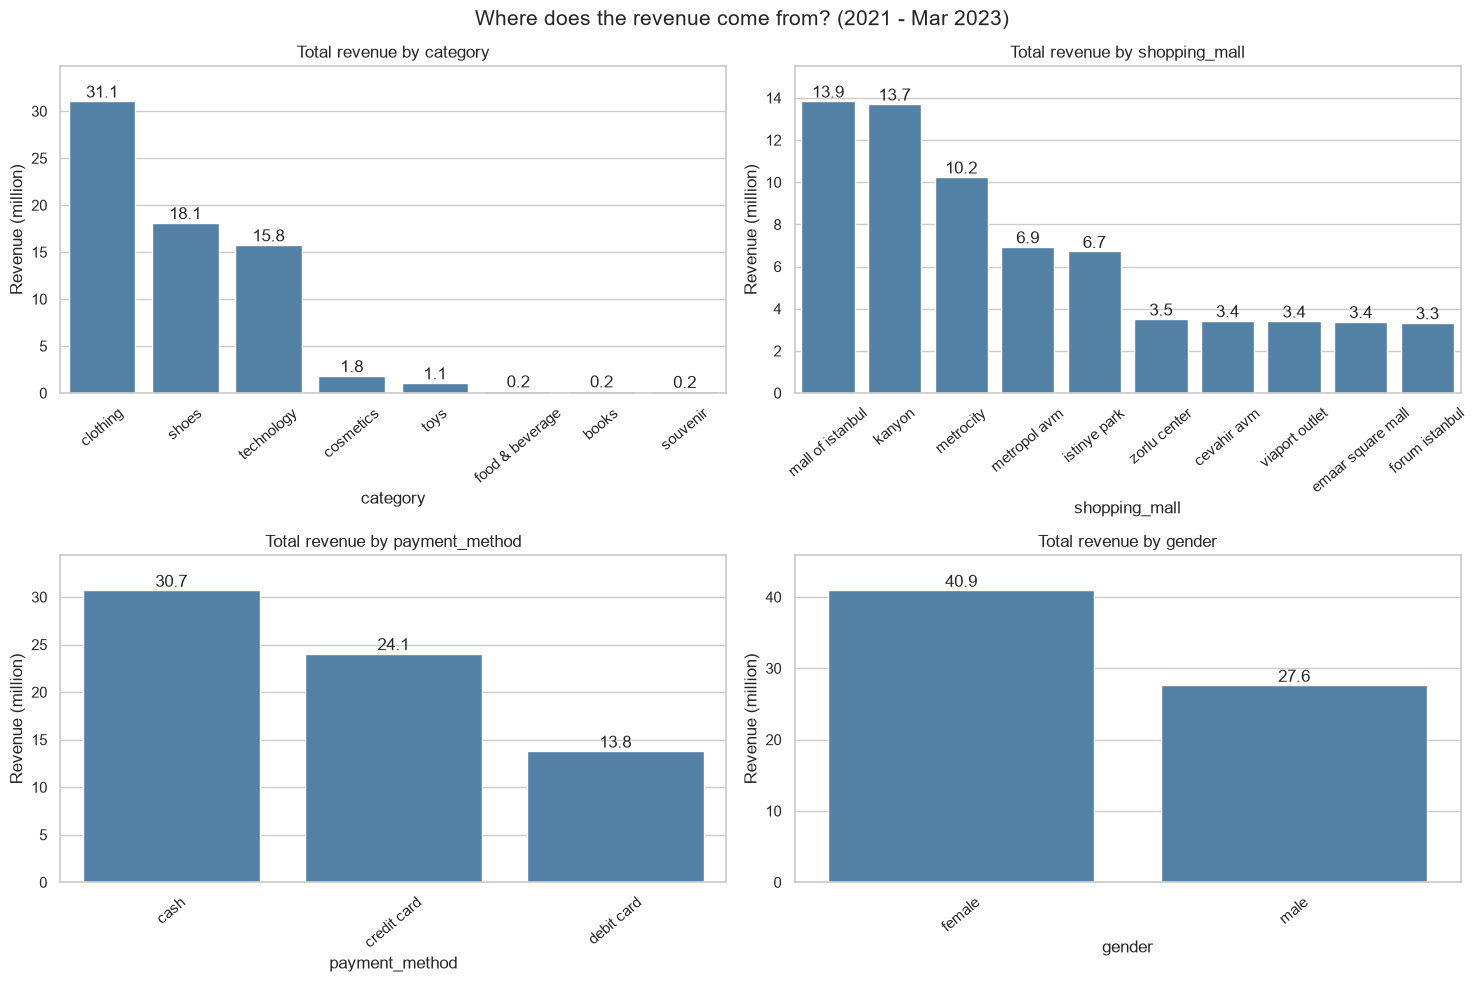

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i in range(4):
    column = spending_columns[i]
    table = spending_tables[column]
    revenue_million = table['total_revenue'] / 1_000_000

    sns.barplot(x=table.index, y=revenue_million, color='steelblue', ax=axes[i])
    axes[i].bar_label(axes[i].containers[0], fmt='%.1f')
    axes[i].margins(y=0.12)
    axes[i].set_title(f'Total revenue by {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Revenue (million)')
    axes[i].tick_params(axis='x', rotation=40)

fig.suptitle('Where does the revenue come from? (2021 - Mar 2023)', fontsize=15)
plt.tight_layout()
plt.show()

### 2. Average purchase per category

In [22]:
category_table = data.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    avg_purchase=('revenue', 'mean'),
    transactions=('revenue', 'count'),
    units_sold=('quantity', 'sum')
)


In [23]:

category_table = category_table.sort_values('total_revenue', ascending=False)

category_table['revenue_rank'] = range(1, len(category_table) + 1)
category_table['transactions_rank'] = category_table['transactions'].rank(ascending=False).astype(int)
category_table['revenue_share_%'] = category_table['total_revenue'] / total_revenue * 100
category_table['cumulative_share_%'] = category_table['revenue_share_%'].cumsum()

category_table = category_table.round(2)
category_table

,total_revenue,avg_purchase,transactions,units_sold,revenue_rank,transactions_rank,revenue_share_%,cumulative_share_%
category,,,,,,,,
clothing,31075684.64,901.08,34487,103558,1,1,45.33,45.33
shoes,18135336.89,1807.39,10034,30217,2,5,26.46,71.79
technology,15772050.00,3156.94,4996,15021,3,7,23.01,94.79
cosmetics,1848606.90,122.45,15097,45465,4,2,2.70,97.49
toys,1086704.64,107.73,10087,30321,5,4,1.59,99.08
food & beverage,231568.71,15.67,14776,44277,6,3,0.34,99.41
books,226977.30,45.57,4981,14982,7,8,0.33,99.75
souvenir,174436.83,34.89,4999,14871,8,6,0.25,100.00


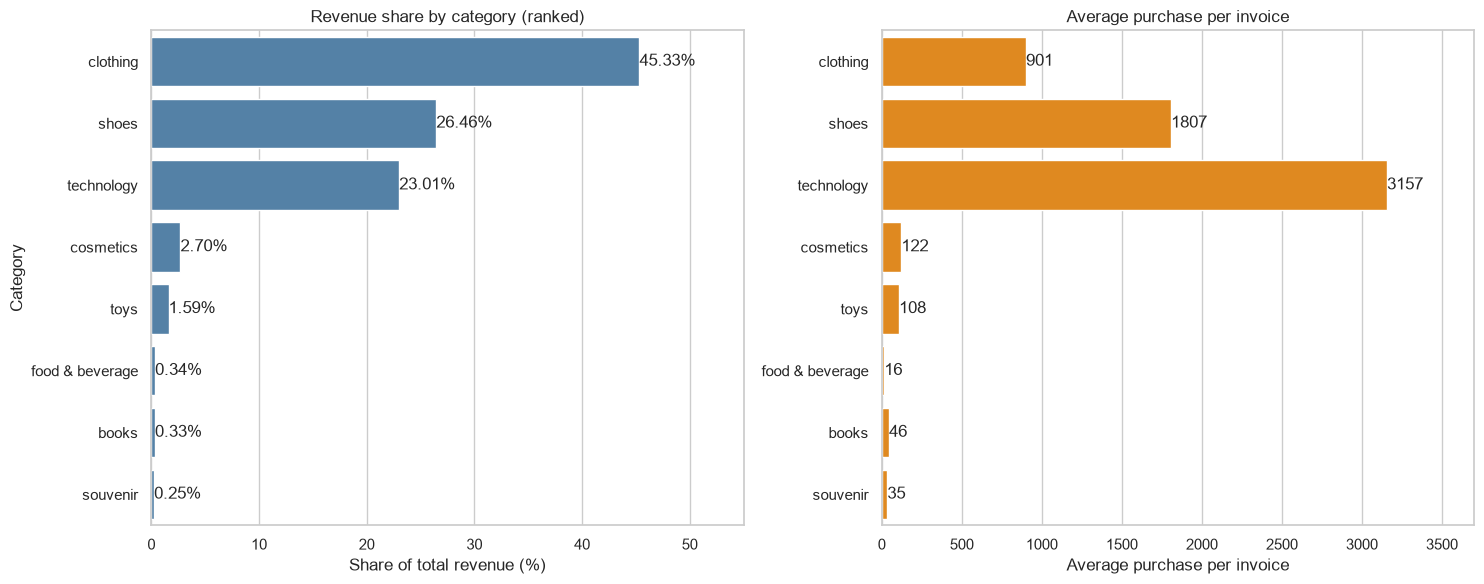

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=category_table['revenue_share_%'], y=category_table.index, color='steelblue', ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fmt='%.2f%%')
axes[0].set_xlim(0, 55)
axes[0].set_title('Revenue share by category (ranked)')
axes[0].set_xlabel('Share of total revenue (%)')
axes[0].set_ylabel('Category')

sns.barplot(x=category_table['avg_purchase'], y=category_table.index, color='darkorange', ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt='%.0f')
axes[1].set_xlim(0, 3700)
axes[1].set_title('Average purchase per invoice')
axes[1].set_xlabel('Average purchase per invoice')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 3. Shopping mall vs category

In [25]:
mall_category = pd.pivot_table(
    data,
    index='shopping_mall',
    columns='category',
    values='revenue',
    aggfunc='sum'
)



In [26]:

mall_category = mall_category[category_table.index]
mall_category['Total'] = mall_category.sum(axis=1)
mall_category = mall_category.sort_values('Total', ascending=False)



In [27]:

mall_category_only = mall_category.drop(columns='Total')

mall_category.loc['Total'] = mall_category.sum()

mall_category.round(0).style.format('{:,.0f}')

category,clothing,shoes,technology,cosmetics,toys,food & beverage,books,souvenir,Total
shopping_mall,,,,,,,,,
mall of istanbul,"6,245,565","3,668,239","3,220,350","373,787","216,151","46,432","46,950","34,263","13,851,738"
kanyon,"6,155,541","3,640,031","3,202,500","372,242","214,502","45,475","44,980","35,483","13,710,755"
metrocity,"4,719,958","2,610,139","2,386,650","272,422","165,258","35,376","34,406","25,771","10,249,980"
metropol avm,"3,166,444","1,942,750","1,465,800","185,776","112,394","23,985","22,240","18,604","6,937,993"
istinye park,"3,050,313","1,806,512","1,509,900","178,741","109,097","23,420","20,725","18,369","6,717,078"
zorlu center,"1,568,818","953,670","803,250","96,974","54,692","11,590","12,256","8,399","3,509,649"
cevahir avm,"1,554,414","884,050","819,000","88,395","55,516","11,992","11,999","8,305","3,433,672"
viaport outlet,"1,530,708","882,850","823,200","92,664","54,620","11,433","10,908","7,636","3,414,019"
emaar square mall,"1,511,803","871,447","834,750","92,380","49,423","11,030","11,060","8,516","3,390,408"


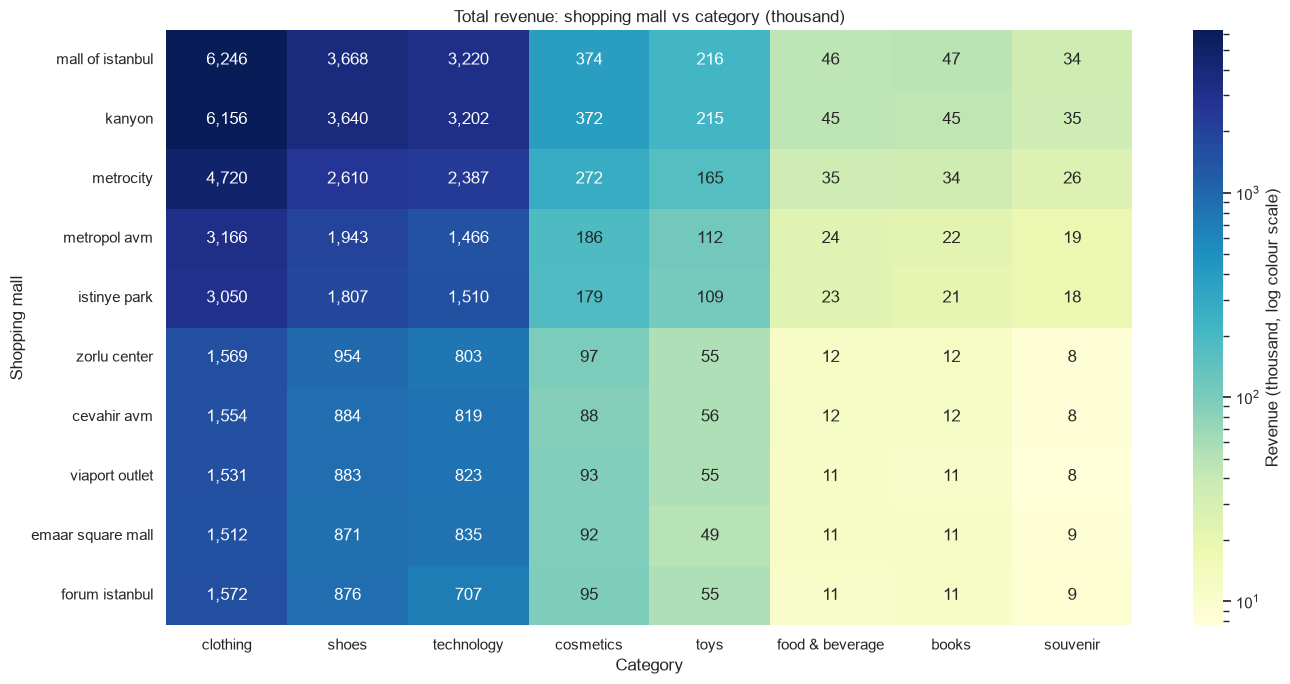

In [28]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    mall_category_only / 1000,
    annot=True,
    fmt=',.0f',
    cmap='YlGnBu',
    norm=LogNorm(),
    cbar_kws={'label': 'Revenue (thousand, log colour scale)'},
    ax=ax
)

ax.set_title('Total revenue: shopping mall vs category (thousand)')
ax.set_xlabel('Category')
ax.set_ylabel('Shopping mall')
plt.tight_layout()
plt.show()

In [29]:
mall_mix = mall_category_only.div(mall_category_only.sum(axis=1), axis=0) * 100
mall_mix = mall_mix.round(1)
mall_mix

category,clothing,shoes,technology,cosmetics,toys,food & beverage,books,souvenir
shopping_mall,,,,,,,,
mall of istanbul,45.1,26.5,23.2,2.7,1.6,0.3,0.3,0.2
kanyon,44.9,26.5,23.4,2.7,1.6,0.3,0.3,0.3
metrocity,46.0,25.5,23.3,2.7,1.6,0.3,0.3,0.3
metropol avm,45.6,28.0,21.1,2.7,1.6,0.3,0.3,0.3
istinye park,45.4,26.9,22.5,2.7,1.6,0.3,0.3,0.3
zorlu center,44.7,27.2,22.9,2.8,1.6,0.3,0.3,0.2
cevahir avm,45.3,25.7,23.9,2.6,1.6,0.3,0.3,0.2
viaport outlet,44.8,25.9,24.1,2.7,1.6,0.3,0.3,0.2
emaar square mall,44.6,25.7,24.6,2.7,1.5,0.3,0.3,0.3


In [30]:

mix_spread = (mall_mix.max() - mall_mix.min()).round(1)
print('Difference between highest and lowest mall share, per category (percentage points):')
mix_spread

Difference between highest and lowest mall share, per category (percentage points):


category
clothing           2.5
shoes              2.5
technology         3.5
cosmetics          0.3
toys               0.2
food & beverage    0.0
books              0.0
souvenir           0.1
dtype: float64

### 4. Yearly revenue

In [31]:
yearly_category = pd.pivot_table(
    data,
    index='category',
    columns='year',
    values='revenue',
    aggfunc='sum'
)
yearly_category = yearly_category.loc[category_table.index]


In [32]:

yearly_category['change_2021_2022_%'] = (yearly_category[2022] / yearly_category[2021] - 1) * 100
yearly_category['change_2021_2022_abs'] = yearly_category[2022] - yearly_category[2021]


In [33]:

yearly_total = yearly_category[[2021, 2022, 2023]].sum()
print('Total revenue per year (2023 is partial):')
print(yearly_total.round(0))
print()
print(f'Total change 2021 -> 2022: {(yearly_total[2022] / yearly_total[2021] - 1) * 100:.2f}%')
print()
yearly_category.round(2)

Total revenue per year (2023 is partial):
year
2021    31316305.0
2022    31372826.0
2023     5862235.0
dtype: float64

Total change 2021 -> 2022: 0.18%



year,2021,2022,2023,change_2021_2022_%,change_2021_2022_abs
category,,,,,
clothing,14365129.68,14070451.12,2640103.84,-2.05,-294678.56
shoes,8242134.61,8378373.20,1514829.08,1.65,136238.59
technology,7104300.00,7268100.00,1399650.00,2.31,163800.00
cosmetics,828081.56,855405.08,165120.26,3.30,27323.52
toys,491294.72,506849.28,88560.64,3.17,15554.56
food & beverage,106179.46,105876.12,19513.13,-0.29,-303.34
books,100065.75,106822.65,20088.90,6.75,6756.90
souvenir,79118.85,80948.73,14369.25,2.31,1829.88


In [34]:

same_period = {}

for year in [2021, 2022, 2023]:
    start = f'{year}-01-01'
    end = f'{year}-03-08'
    mask = (data['invoice_date'] >= start) & (data['invoice_date'] <= end)
    same_period[year] = data[mask].groupby('category')['revenue'].sum()


In [35]:

same_period_table = pd.DataFrame(same_period).loc[category_table.index]
same_period_table.loc['Total'] = same_period_table.sum()


In [36]:

same_period_table['change_2022_2023_%'] = (same_period_table[2023] / same_period_table[2022] - 1) * 100
same_period_table.round(2)

,2021,2022,2023,change_2022_2023_%
category,,,,
clothing,2573786.16,2589390.32,2640103.84,1.96
shoes,1571245.06,1406798.48,1514829.08,7.68
technology,1244250.00,1318800.00,1399650.00,6.13
cosmetics,147229.86,153166.22,165120.26,7.80
toys,88417.28,95764.48,88560.64,-7.52
food & beverage,18289.31,18608.34,19513.13,4.86
books,19058.70,19316.25,20088.90,4.00
souvenir,15448.41,16985.04,14369.25,-15.40
Total,5677724.78,5618829.13,5862235.10,4.33


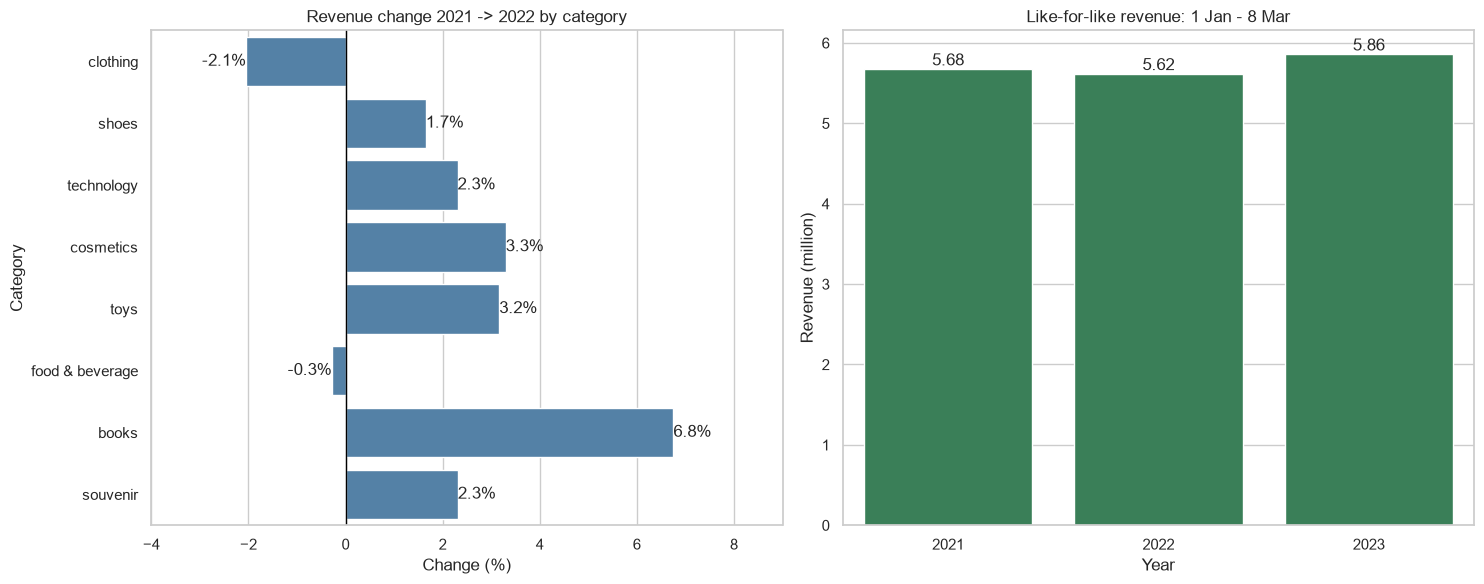

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


change = yearly_category['change_2021_2022_%']
sns.barplot(x=change.values, y=change.index, color='steelblue', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')
axes[0].set_xlim(-4, 9)
axes[0].set_title('Revenue change 2021 -> 2022 by category')
axes[0].set_xlabel('Change (%)')
axes[0].set_ylabel('Category')


period_total = same_period_table.loc['Total', [2021, 2022, 2023]] / 1_000_000
sns.barplot(x=period_total.index.astype(str), y=period_total.values, color='seagreen', ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt='%.2f')
axes[1].set_title('Like-for-like revenue: 1 Jan - 8 Mar')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Revenue (million)')

plt.tight_layout()
plt.show()

In [38]:

monthly = data.groupby(['month', 'year'])['revenue'].sum().unstack() / 1_000_000


monthly.loc[3, 2023] = np.nan


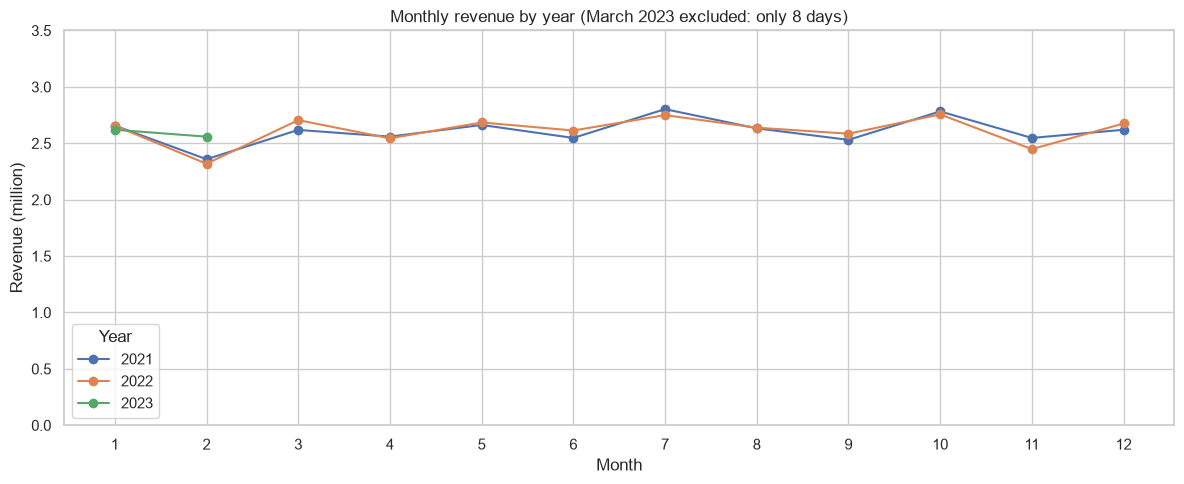

In [39]:

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(marker='o', ax=ax)
ax.set_ylim(0, 3.5)
ax.set_xticks(range(1, 13))
ax.set_title('Monthly revenue by year (March 2023 excluded: only 8 days)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (million)')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

### 5. Male vs female

In [40]:
gender_revenue = pd.pivot_table(data, index='category', columns='gender', values='revenue', aggfunc='sum')
gender_avg = pd.pivot_table(data, index='category', columns='gender', values='revenue', aggfunc='mean')
gender_count = pd.pivot_table(data, index='category', columns='gender', values='revenue', aggfunc='count')


In [41]:

gender_revenue = gender_revenue.loc[category_table.index]
gender_avg = gender_avg.loc[category_table.index]
gender_count = gender_count.loc[category_table.index]


In [42]:

print('Total revenue by category and gender:')
display(gender_revenue.round(0))
print('Average purchase by category and gender:')
display(gender_avg.round(2))
print('Number of transactions by category and gender:')
display(gender_count)

Total revenue by category and gender:


gender,female,male
category,,
clothing,18616663.0,12459022.0
shoes,10746644.0,7388693.0
technology,9425850.0,6346200.0
cosmetics,1108432.0,740175.0
toys,658094.0,428611.0
food & beverage,137873.0,93695.0
books,132956.0,94021.0
souvenir,105288.0,69148.0


Average purchase by category and gender:


gender,female,male
category,,
clothing,901.45,900.54
shoes,1801.01,1816.74
technology,3161.98,3149.48
cosmetics,122.21,122.81
toys,108.15,107.10
food & beverage,15.66,15.69
books,45.75,45.31
souvenir,34.90,34.89


Number of transactions by category and gender:


gender,female,male
category,,
clothing,20652,13835
shoes,5967,4067
technology,2981,2015
cosmetics,9070,6027
toys,6085,4002
food & beverage,8804,5972
books,2906,2075
souvenir,3017,1982


In [43]:

gender_mix = gender_revenue / gender_revenue.sum() * 100


female_share = gender_revenue['female'] / gender_revenue.sum(axis=1) * 100
overall_female_share = data[data['gender'] == 'female']['revenue'].sum() / total_revenue * 100


In [44]:

print(f'Female share of total revenue: {overall_female_share:.1f}%')
print()
summary = pd.DataFrame({
    'female_mix_%': gender_mix['female'],
    'male_mix_%': gender_mix['male'],
    'female_share_of_category_%': female_share
})
summary.round(2)

Female share of total revenue: 59.7%



,female_mix_%,male_mix_%,female_share_of_category_%
category,,,
clothing,45.48,45.11,59.91
shoes,26.25,26.75,59.26
technology,23.03,22.98,59.76
cosmetics,2.71,2.68,59.96
toys,1.61,1.55,60.56
food & beverage,0.34,0.34,59.54
books,0.32,0.34,58.58
souvenir,0.26,0.25,60.36


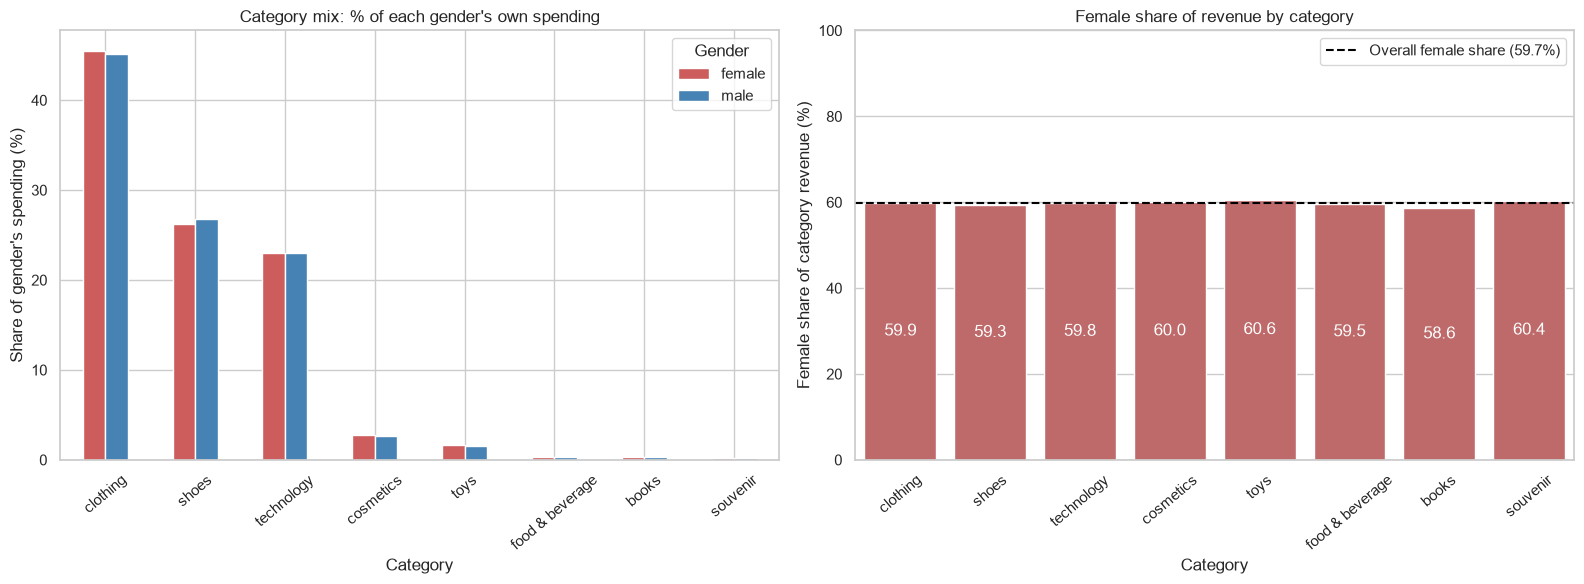

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


gender_mix.plot(kind='bar', ax=axes[0], color=['indianred', 'steelblue'])
axes[0].set_title("Category mix: % of each gender's own spending")
axes[0].set_xlabel('Category')
axes[0].set_ylabel("Share of gender's spending (%)")
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(title='Gender')


sns.barplot(x=female_share.index, y=female_share.values, color='indianred', ax=axes[1])
axes[1].axhline(overall_female_share, color='black', linestyle='--', label=f'Overall female share ({overall_female_share:.1f}%)')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f', label_type='center', color='white')
axes[1].set_ylim(0, 100)
axes[1].set_title('Female share of revenue by category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Female share of category revenue (%)')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend()

plt.tight_layout()
plt.show()

In [46]:
alpha = 0.05 / len(category_table)
test_rows = []

for category in category_table.index:
    female_spend = data[(data['category'] == category) & (data['gender'] == 'female')]['revenue']
    male_spend = data[(data['category'] == category) & (data['gender'] == 'male')]['revenue']

    t_stat, p_value = stats.ttest_ind(female_spend, male_spend, equal_var=False)

    test_rows.append({
        'category': category,
        'female_avg': female_spend.mean(),
        'male_avg': male_spend.mean(),
        'p_value': p_value,
        'significant': p_value < alpha
    })

gender_tests = pd.DataFrame(test_rows).set_index('category').round(4)
print(f'Bonferroni significance limit: {alpha:.5f}')
gender_tests

Bonferroni significance limit: 0.00625


,female_avg,male_avg,p_value,significant
category,,,,
clothing,901.4460,900.5437,0.8467,False
shoes,1801.0129,1816.7428,0.3588,False
technology,3161.9758,3149.4789,0.7695,False
cosmetics,122.2086,122.8098,0.5291,False
toys,108.1502,107.0991,0.3053,False
food & beverage,15.6603,15.6891,0.8169,False
books,45.7524,45.3113,0.4760,False
souvenir,34.8984,34.8882,0.9830,False


### 6. İnsights

**Insight 1 — Protect the three core categories**

* **FACT:** Clothing, Shoes, and Technology generate **94.8% of revenue** and **49.8% of invoices**.
* **ACTION:** Prioritize these categories in leasing and space decisions and prepare backup plans for key tenants.
* **CONFIDENCE:** High. Floor-area and rent data are needed for space decisions.

**Insight 2 — High-frequency categories are not major revenue drivers**

* **FACT:** Cosmetics, Food & Beverage, and Toys make up **40.2% of invoices but only 4.6% of revenue**.
* **ACTION:** Track footfall and repeat visits, not just revenue. Collect basket-level data to measure cross-selling.
* **CONFIDENCE:** Medium. Their role as traffic drivers is not yet proven.

**Insight 3 — Mall differences are mainly about transaction volume**

* **FACT:** Average invoice value is similar across malls (**674–705**), but transaction volumes vary significantly.
* **ACTION:** For lower-volume malls, focus on increasing **footfall and invoices per month** through events, campaigns, and accessibility improvements.
* **CONFIDENCE:** Medium. Footfall data is needed to confirm the cause.

**Insight 4 — Revenue is flat; monitor Clothing**

* **FACT:** Revenue grew only **0.18% from 2021 to 2022**. Clothing fell **2.05%**, while Jan–Mar 2023 revenue was **4.3% higher** than the same period in 2022.
* **ACTION:** Track monthly performance of the top 3 categories and flag declines versus the previous year.
* **CONFIDENCE:** Low–Medium. The 2023 period is too short to confirm a trend.

**Insight 5 — Gender and payment method have little impact on invoice value**

* **FACT:** Average invoice value is almost identical by gender (**688 vs 691**) and payment method (**687–691**).
* **ACTION:** Avoid separate strategies based only on ticket size. Test targeted campaigns with control groups and evaluate them by incremental revenue and traffic.
* **CONFIDENCE:** High for invoice-value differences; medium for campaign ideas.